In [2]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"D:\downloadss\airline_route_profitability.csv")

In [5]:
print("rows:", df.shape[0])
print("column:", df.shape[1])
df.head()


rows: 7974
column: 33


,Flight_Number,Flight_Date,Origin,Destination,Route,Aircraft_Type,Aircraft_Capacity,Passengers,Load_Factor,Flight_Hours,...,Handling_Cost,Navigation_Fees,Sales_Distribution_Cost,Passenger_Service_Cost,Overhead_Cost,Marketing_Cost,IT_Systems_Cost,Total_Cost,Profit,Profit_Margin
0,EK8960,2024-12-20,DXB,ORD,DXB-ORD,Boeing 777-300ER,396,308,0.7791,14.5,...,4460.11,10636.90,78193.60,5100.09,88545.73,25883.92,3769.37,506421.77,-42204.34,-9.09
1,EK3960,2024-05-13,DXB,HYD,DXB-HYD,Boeing 787-9,296,234,0.7910,4.2,...,5425.84,3027.25,21586.21,6022.20,17057.61,8820.56,1937.81,123323.88,40261.57,24.61
2,EK7529,2024-10-12,DXB,CDG,DXB-CDG,Boeing 787-9,296,251,0.8502,7.5,...,3761.85,3431.70,100188.97,6514.22,31347.38,23695.34,3415.99,282266.09,399299.10,58.59
3,EK4543,2024-06-25,DXB,DEL,DXB-DEL,Boeing 787-9,296,229,0.7748,3.5,...,4440.93,2079.79,22686.82,4791.21,15328.62,6795.49,2245.61,113919.11,30109.31,20.91
4,EK3114,2024-04-20,DXB,RUH,DXB-RUH,Airbus A320,180,142,0.7901,2.2,...,3414.18,1662.49,5133.62,3094.65,8252.23,1492.53,1273.27,46580.86,-10058.06,-27.54


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7974 entries, 0 to 7973
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Flight_Number            7974 non-null   object 
 1   Flight_Date              7974 non-null   object 
 2   Origin                   7974 non-null   object 
 3   Destination              7974 non-null   object 
 4   Route                    7974 non-null   object 
 5   Aircraft_Type            7974 non-null   object 
 6   Aircraft_Capacity        7974 non-null   int64  
 7   Passengers               7974 non-null   int64  
 8   Load_Factor              7974 non-null   float64
 9   Flight_Hours             7974 non-null   float64
 10  Season                   7974 non-null   object 
 11  Route_Category           7974 non-null   object 
 12  Demand_Level             7974 non-null   object 
 13  Ticket_Revenue           7974 non-null   float64
 14  Ancillary_Revenue       

In [7]:
print("Dataset Shape:", df.shape)
print(df.columns.tolist())

Dataset Shape: (7974, 33)
['Flight_Number', 'Flight_Date', 'Origin', 'Destination', 'Route', 'Aircraft_Type', 'Aircraft_Capacity', 'Passengers', 'Load_Factor', 'Flight_Hours', 'Season', 'Route_Category', 'Demand_Level', 'Ticket_Revenue', 'Ancillary_Revenue', 'Total_Revenue', 'Fuel_Cost', 'Maintenance_Cost', 'Crew_Cost', 'Depreciation_Cost', 'Insurance_Cost', 'Airport_Fees', 'Catering_Cost', 'Handling_Cost', 'Navigation_Fees', 'Sales_Distribution_Cost', 'Passenger_Service_Cost', 'Overhead_Cost', 'Marketing_Cost', 'IT_Systems_Cost', 'Total_Cost', 'Profit', 'Profit_Margin']


In [8]:
missing = df.isnull().sum()

print("Missing Values:")
print(missing[missing > 0])

Missing Values:
Ancillary_Revenue    271
Catering_Cost        265
Handling_Cost        256
dtype: int64


In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Aircraft_Capacity,7974.0,317.800602,98.768543,180.0000,296.000000,325.0000,396.0000,517.00
Passengers,7974.0,254.819162,88.141968,104.0000,180.250000,246.0000,302.0000,491.00
Load_Factor,7974.0,0.801570,0.087755,0.5766,0.736825,0.8015,0.8731,0.95
Flight_Hours,7974.0,6.327314,4.555668,1.2000,3.200000,4.5000,7.5000,16.50
Ticket_Revenue,7974.0,264383.873745,237102.214088,14812.3400,56429.512500,182620.3550,412696.9325,1303644.62
Ancillary_Revenue,7703.0,33073.717197,30167.518230,1616.6200,7234.405000,22842.8500,51234.9750,192921.91
Total_Revenue,7974.0,297436.197695,266832.892069,16650.0200,63502.390000,204812.5900,463800.2450,1496566.53
Fuel_Cost,7974.0,46296.405878,43123.036900,2592.6200,16137.575000,28344.9500,74832.9600,191047.78
Maintenance_Cost,7974.0,18973.224856,17677.194300,1380.0000,7040.000000,11200.0000,30800.0000,72500.00
Crew_Cost,7974.0,8905.116880,7414.772748,936.0000,3840.000000,5850.0000,13000.0000,29000.00


## Categorical Overview

In [11]:


print("Unique Routes:", df["Route"].nunique())
print("Origin Airports:", df["Origin"].unique())
print("Destination Airport:", df["Destination"].unique())
print("Aircraft Type:", df["Aircraft_Type"].unique())


print("\nDemand Levels:\n", df["Demand_Level"].value_counts())

print("\nSeasons:\n", df["Season"].value_counts())

print("\nAircraft Type:\n", df["Aircraft_Type"].value_counts())

Unique Routes: 30
Origin Airports: ['DXB']
Destination Airport: ['ORD' 'HYD' 'CDG' 'DEL' 'RUH' 'KWI' 'IST' 'DOH' 'BKK' 'HKG' 'SFO' 'BAH'
 'AMM' 'JFK' 'FRA' 'MEL' 'MCT' 'BLR' 'KUL' 'LHE' 'LHR' 'SYD' 'SIN' 'BOM'
 'CMB' 'LAX' 'MAA' 'KHI' 'JED' 'CAI']
Aircraft Type: ['Boeing 777-300ER' 'Boeing 787-9' 'Airbus A320' 'Boeing 737-800'
 'Airbus A350-900' 'Airbus A380']

Demand Levels:
 Demand_Level
High      4630
Medium    3344
Name: count, dtype: int64

Seasons:
 Season
Shoulder    2646
Peak        2002
Low         2001
Normal      1325
Name: count, dtype: int64

Aircraft Type:
 Aircraft_Type
Boeing 787-9        1818
Airbus A350-900     1700
Boeing 777-300ER    1690
Boeing 737-800      1017
Airbus A320          956
Airbus A380          793
Name: count, dtype: int64


## 1. Revenue, cost & Profit Summary

In [12]:
financial_summary = df[
    ["Ticket_Revenue", "Ancillary_Revenue", "Total_Revenue", "Total_Cost", "Profit", "Profit_Margin"]
].describe().T

financial_summary

,count,mean,std,min,25%,50%,75%,max
Ticket_Revenue,7974.0,264383.873745,237102.214088,14812.34,56429.5125,182620.355,412696.9325,1303644.62
Ancillary_Revenue,7703.0,33073.717197,30167.518230,1616.62,7234.4050,22842.850,51234.9750,192921.91
Total_Revenue,7974.0,297436.197695,266832.892069,16650.02,63502.3900,204812.590,463800.2450,1496566.53
Total_Cost,7974.0,225266.563756,174526.327680,28019.38,83612.3675,154808.355,355441.0025,835108.70
Profit,7974.0,72169.633934,138692.750890,-250914.85,-9052.4850,21326.055,116046.0900,972133.76
Profit_Margin,7974.0,6.190222,39.040588,-236.27,-10.7475,15.215,33.2800,64.96


## 2. Profit Distribution

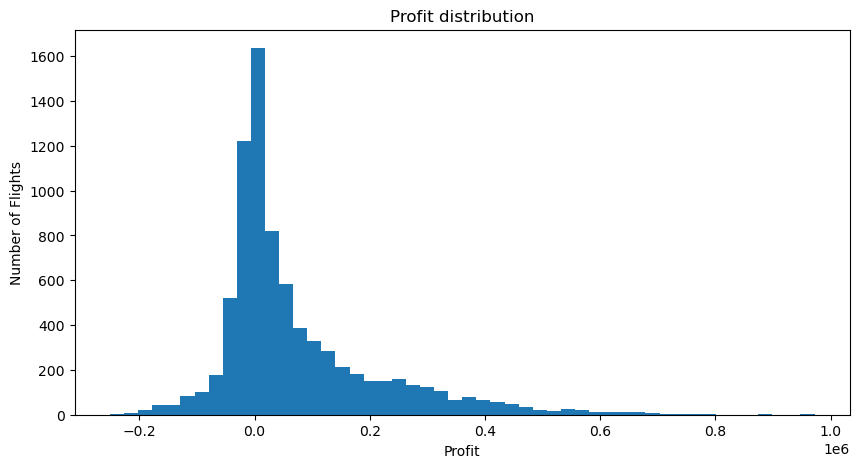

In [13]:
plt.figure(figsize=(10,5))
plt.hist(df["Profit"], bins=50)

plt.title("Profit distribution")
plt.xlabel("Profit")
plt.ylabel("Number of Flights")
plt.show()


## 3. Revenue vs Cost

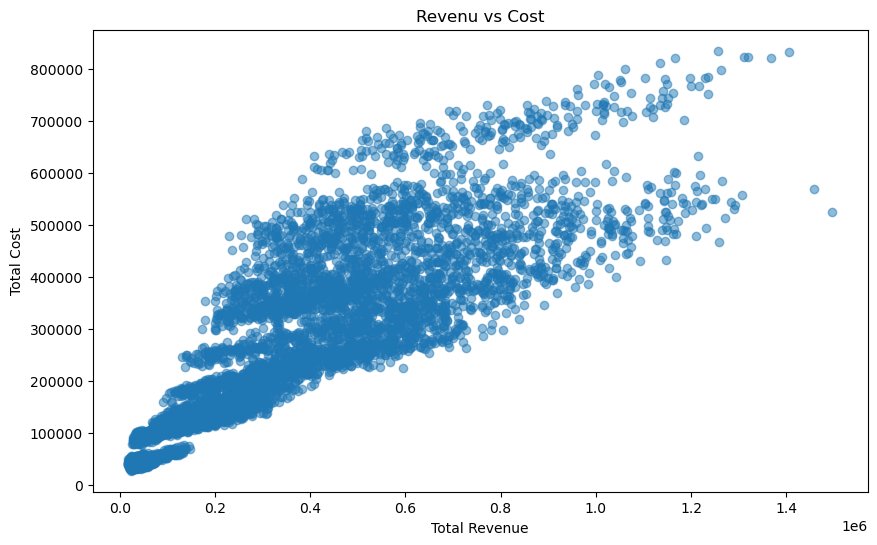

In [14]:
plt.figure(figsize= (10,6))

plt.scatter(
    df["Total_Revenue"],
    df["Total_Cost"],
    alpha = 0.5
)
plt.title("Revenu vs Cost")
plt.xlabel("Total Revenue")
plt.ylabel("Total Cost")
plt.show()

## 4. Route Profitability Analysis

In [15]:
route_analysis = (
    df.groupby("Route")
        .agg(
            Flights=("Flight_Number", "count"),
            Passengers=("Passengers", "sum"),
            Revenue=("Total_Revenue", "sum"),
            Cost=("Total_Cost", "sum"),
            Profit=("Profit", "sum"),
            Avg_Load_Factor=("Load_Factor", "mean"),
            Avg_Profit_Margin=("Profit_Margin", "mean"),
            
        )
    .sort_values("Profit", ascending=False)
)
route_analysis

,Flights,Passengers,Revenue,Cost,Profit,Avg_Load_Factor,Avg_Profit_Margin
Route,,,,,,,
DXB-FRA,325,109787,2.048922e+08,1.054007e+08,99491502.54,0.850049,46.080000
DXB-SIN,320,109749,2.039344e+08,1.129396e+08,90994879.30,0.849792,42.072750
DXB-CDG,323,110676,2.039859e+08,1.138073e+08,90178585.87,0.853367,41.265944
DXB-HKG,332,116223,2.182465e+08,1.287146e+08,89531878.76,0.851442,38.667681
DXB-JFK,328,113213,2.137032e+08,1.724657e+08,41237491.55,0.851404,15.704177
DXB-BKK,212,56490,9.495948e+07,5.439553e+07,40563948.78,0.740103,39.905236
DXB-KUL,216,56747,9.641778e+07,5.993626e+07,36481521.99,0.727525,34.485741
DXB-SYD,327,111906,2.053551e+08,1.742288e+08,31126294.37,0.848955,9.975076
DXB-BOM,325,93740,6.903962e+07,4.496927e+07,24070355.00,0.848457,31.157938


## 5. Top 10 Routes by Profit

In [16]:
top_routes = route_analysis.head(10)
top_routes

,Flights,Passengers,Revenue,Cost,Profit,Avg_Load_Factor,Avg_Profit_Margin
Route,,,,,,,
DXB-FRA,325,109787,2.048922e+08,1.054007e+08,99491502.54,0.850049,46.080000
DXB-SIN,320,109749,2.039344e+08,1.129396e+08,90994879.30,0.849792,42.072750
DXB-CDG,323,110676,2.039859e+08,1.138073e+08,90178585.87,0.853367,41.265944
DXB-HKG,332,116223,2.182465e+08,1.287146e+08,89531878.76,0.851442,38.667681
DXB-JFK,328,113213,2.137032e+08,1.724657e+08,41237491.55,0.851404,15.704177
DXB-BKK,212,56490,9.495948e+07,5.439553e+07,40563948.78,0.740103,39.905236
DXB-KUL,216,56747,9.641778e+07,5.993626e+07,36481521.99,0.727525,34.485741
DXB-SYD,327,111906,2.053551e+08,1.742288e+08,31126294.37,0.848955,9.975076
DXB-BOM,325,93740,6.903962e+07,4.496927e+07,24070355.00,0.848457,31.157938


## 6. Bottom 10 Routes by Profit

In [17]:
bottom_routes = route_analysis.tail(10).sort_values("Profit")
bottom_routes

,Flights,Passengers,Revenue,Cost,Profit,Avg_Load_Factor,Avg_Profit_Margin
Route,,,,,,,
DXB-CAI,201,46011,11678327.29,1.986855e+07,-8190219.81,0.735169,-83.958159
DXB-AMM,219,50040,12448226.61,2.036120e+07,-7912976.35,0.739424,-76.294155
DXB-LAX,206,54629,87417926.51,9.532329e+07,-7905366.81,0.735038,-15.592718
DXB-LHR,344,117071,84140583.59,9.084016e+07,-6699578.75,0.850903,-13.442500
DXB-SFO,210,55545,94070676.65,1.000649e+08,-5994202.11,0.735600,-12.707810
DXB-JED,205,27608,6722705.20,1.059964e+07,-3876933.27,0.731225,-68.188488
DXB-RUH,216,29139,7278877.32,9.690177e+06,-2411299.99,0.733216,-41.197731
DXB-KWI,341,53401,15174911.77,1.580494e+07,-630031.24,0.851329,-10.633431
DXB-DOH,338,52879,14789844.81,1.414385e+07,645992.38,0.848886,-0.979734


## 7. Top Routes Chart

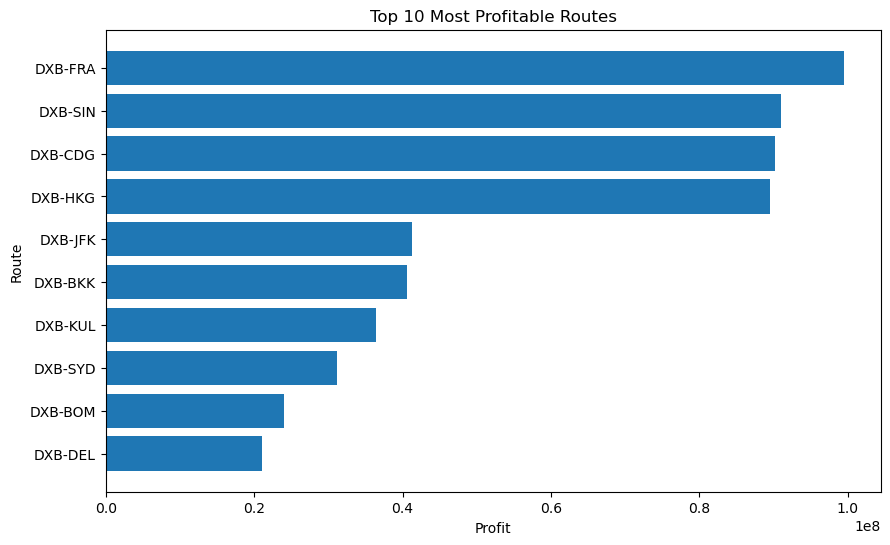

In [18]:
top10 = route_analysis.head(10).sort_values("Profit")

plt.figure(figsize=(10,6))
plt.barh(
    top10.index,
    top10["Profit"]
)

plt.title("Top 10 Most Profitable Routes")
plt.xlabel("Profit")
plt.ylabel("Route")
plt.show()

## 8. Loss Making Routes

In [19]:
loss_routes = route_analysis[route_analysis["Profit"] < 0]

print("Loss_making routes:", len(loss_routes))
loss_routes.sort_values("Profit").head(10)


Loss_making routes: 8


,Flights,Passengers,Revenue,Cost,Profit,Avg_Load_Factor,Avg_Profit_Margin
Route,,,,,,,
DXB-CAI,201,46011,11678327.29,1.986855e+07,-8190219.81,0.735169,-83.958159
DXB-AMM,219,50040,12448226.61,2.036120e+07,-7912976.35,0.739424,-76.294155
DXB-LAX,206,54629,87417926.51,9.532329e+07,-7905366.81,0.735038,-15.592718
DXB-LHR,344,117071,84140583.59,9.084016e+07,-6699578.75,0.850903,-13.442500
DXB-SFO,210,55545,94070676.65,1.000649e+08,-5994202.11,0.735600,-12.707810
DXB-JED,205,27608,6722705.20,1.059964e+07,-3876933.27,0.731225,-68.188488
DXB-RUH,216,29139,7278877.32,9.690177e+06,-2411299.99,0.733216,-41.197731
DXB-KWI,341,53401,15174911.77,1.580494e+07,-630031.24,0.851329,-10.633431


## 9. Load Factor Analysis

In [20]:
print(df["Load_Factor"].describe())

count    7974.000000
mean        0.801570
std         0.087755
min         0.576600
25%         0.736825
50%         0.801500
75%         0.873100
max         0.950000
Name: Load_Factor, dtype: float64


## 10. Load Factor vs Profit

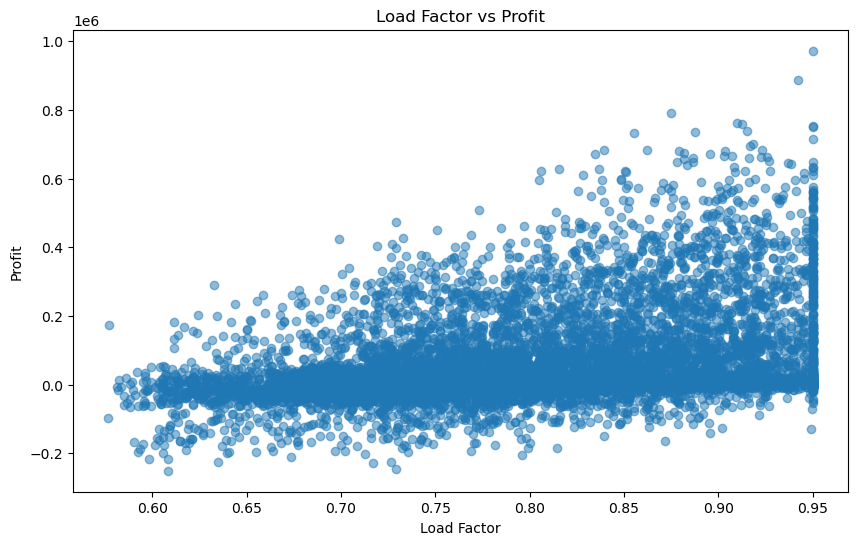

In [21]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Load_Factor"],
    df["Profit"],
    alpha=0.5
)

plt.title("Load Factor vs Profit")
plt.xlabel("Load Factor")
plt.ylabel("Profit")
plt.show()
    

## 11. Demand Level analysis

In [22]:
demand_analysis = (
    df.groupby("Demand_Level")
      .agg(
          Flights=("Flight_Number", "count"),
          Passengers=("Passengers", "sum"),
          Revenue=("Total_Revenue", "sum"),
          Cost=("Total_Cost", "sum"),
          Profit=("Profit", "sum"),
          Avg_Profit_Margin=("Profit_Margin", "mean")
    )
    .sort_values("Profit", ascending=False)
)


## Average profit chart

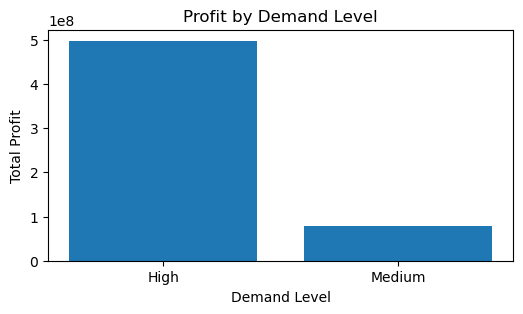

In [23]:
plt.figure(figsize=(6, 3))

plt.bar(
    demand_analysis.index,
    demand_analysis["Profit"]
)

plt.title("Profit by Demand Level")
plt.xlabel("Demand Level")
plt.ylabel("Total Profit")

plt.show()

## 12. Season Analysis

In [24]:
season_analysis = (
    df.groupby("Season")
    .agg(
        Flights=("Flight_Number", "count"),
        Passengers=("Passengers", "sum"),
        Revenue=("Total_Revenue", "sum"),
        Cost=("Total_Cost", "sum"),
        Profit=("Profit", "sum"),
        Avg_Load_Factor=("Load_Factor", "mean"),
        Avg_Profit_Mirgin=("Profit_Margin", "mean"),
    )
    .sort_values("Profit", ascending=False)
)

season_analysis

,Flights,Passengers,Revenue,Cost,Profit,Avg_Load_Factor,Avg_Profit_Mirgin
Season,,,,,,,
Peak,2002,550507,6.918343e+08,4.710562e+08,2.207781e+08,0.869934,17.546783
Shoulder,2646,694535,8.273671e+08,6.086088e+08,2.187583e+08,0.822007,10.139067
Normal,1325,328391,3.750061e+08,2.908944e+08,8.411166e+07,0.781693,3.330891
Low,2001,458495,4.775488e+08,4.257161e+08,5.183267e+07,0.719308,-8.500365


## Profit by Season (Chart)

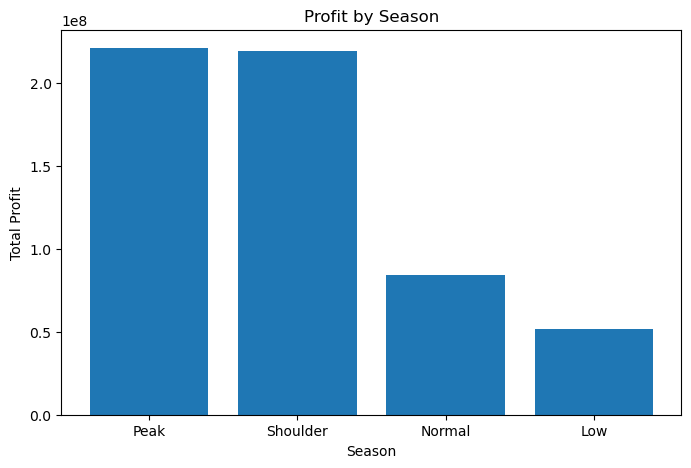

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    season_analysis.index,
    season_analysis["Profit"]
)

plt.title("Profit by Season")
plt.xlabel("Season")
plt.ylabel("Total Profit")

plt.show()

## 13. Aircraft Performance

In [26]:
aircraft_analysis = (
    df.groupby("Aircraft_Type")
    .agg(
        Flights=("Flight_Number", "count"),
        Passengers=("Passengers", "sum"),
        Revenue=("Total_Revenue", "sum"),
        Cost=("Total_Cost", "sum"),
        Profit=("Profit", "sum"),
        Avg_Load_Factor=("Load_Factor", "mean"),
        Avg_Profit_Margin=("Profit_Margin", "mean"),
    )
    .sort_values("Profit", ascending=False)
)

aircraft_analysis

,Flights,Passengers,Revenue,Cost,Profit,Avg_Load_Factor,Avg_Profit_Margin
Aircraft_Type,,,,,,,
Boeing 777-300ER,1690,539074,8.103012e+08,6.151625e+08,1.951387e+08,0.806732,17.259136
Airbus A380,793,347221,5.858770e+08,4.047700e+08,1.811070e+08,0.847843,23.181375
Boeing 787-9,1818,431999,4.713439e+08,3.377598e+08,1.335841e+08,0.804445,9.478240
Airbus A350-900,1700,418650,4.123968e+08,3.498251e+08,6.257166e+07,0.759275,1.040706
Airbus A320,956,139193,4.447098e+07,4.242683e+07,2.044150e+06,0.811496,-7.872992
Boeing 737-800,1017,155791,4.736636e+07,4.633135e+07,1.035013e+06,0.813140,-9.502458


## 14. Cost Component Analysis

In [27]:
cost_columns = [
    "Fuel_Cost",
    "Maintenance_Cost",
    "Crew_Cost",
    "Depreciation_Cost",
    "Insurance_Cost",
    "Airport_Fees",
    "Catering_Cost",
    "Handling_Cost",
    "Navigation_Fees",
    "Sales_Distribution_Cost",
    "Passenger_Service_Cost",
    "Overhead_Cost",
    "Marketing_Cost",
    "IT_Systems_Cost",
]

cost_summary = df[cost_columns].sum().sort_values(ascending=False)
cost_summary

Fuel_Cost                  3.691675e+08
Sales_Distribution_Cost    3.561128e+08
Overhead_Cost              2.850088e+08
Depreciation_Cost          2.014138e+08
Maintenance_Cost           1.512925e+08
Marketing_Cost             1.072358e+08
Crew_Cost                  7.100940e+07
Catering_Cost              4.624435e+07
Passenger_Service_Cost     4.562709e+07
Airport_Fees               4.030786e+07
Insurance_Cost             3.592244e+07
Handling_Cost              3.078709e+07
Navigation_Fees            3.018613e+07
IT_Systems_Cost            2.336971e+07
dtype: float64

## Chart

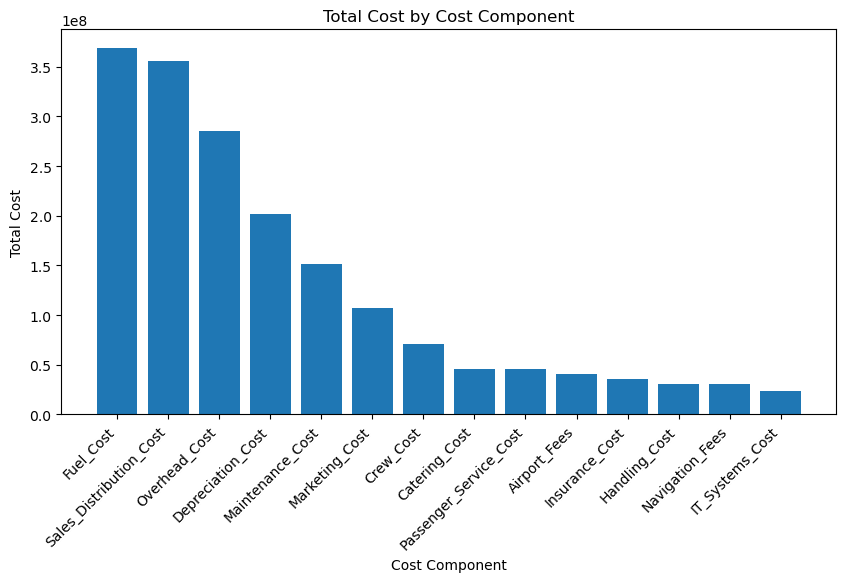

In [33]:
plt.figure(figsize=(10,5))

plt.bar(
    cost_summary.index,
    cost_summary.values
)

plt.title("Total Cost by Cost Component")
plt.xlabel("Cost Component")
plt.ylabel("Total Cost")
plt.xticks(rotation=45, ha="right")
plt.show()

## 15. Passengers vs Revenue

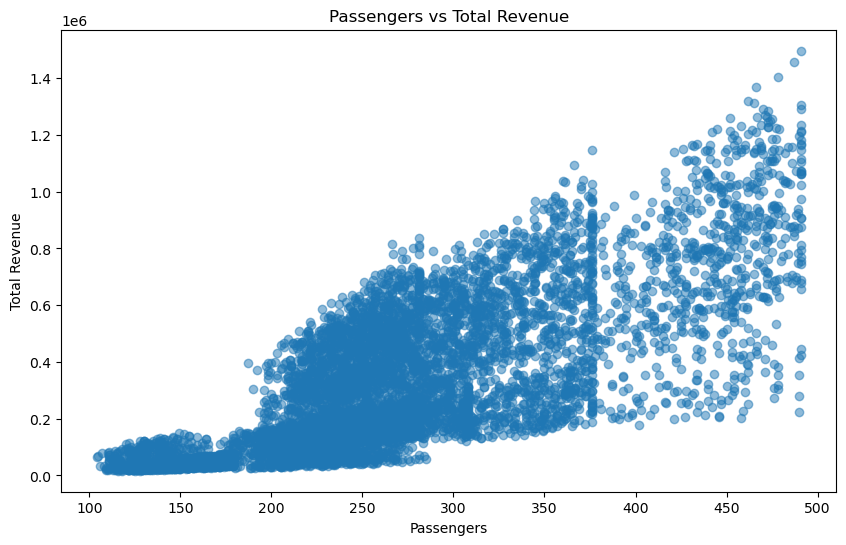

In [34]:
plt.figure(figsize=(10,6))
plt.scatter(
    df["Passengers"],
    df["Total_Revenue"],
    alpha=0.5
)

plt.title("Passengers vs Total Revenue")
plt.xlabel("Passengers")
plt.ylabel("Total Revenue")
plt.show()

## 16. Flight Hours vs Cost

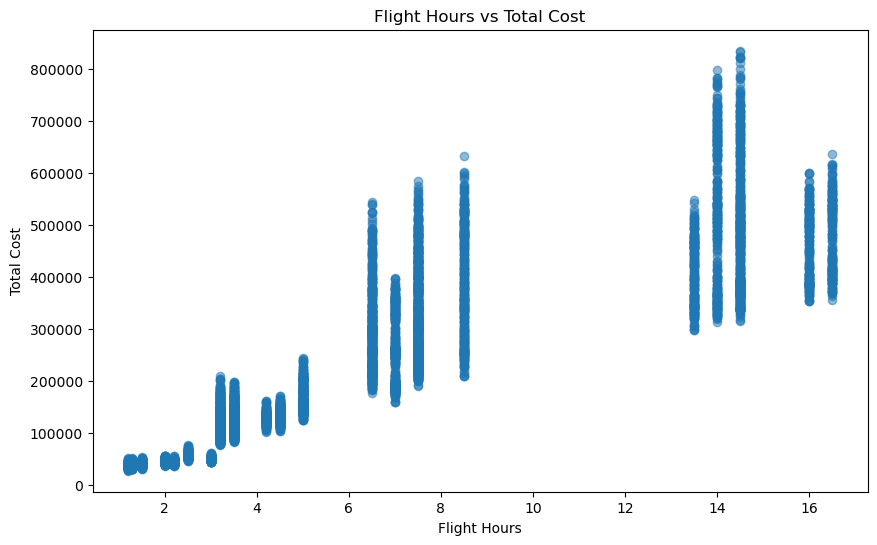

In [37]:
plt.figure(figsize=(10,6))
plt.scatter(
    df["Flight_Hours"],
    df["Total_Cost"],
    alpha=0.5
)
plt.title("Flight Hours vs Total Cost")
plt.xlabel("Flight Hours")
plt.ylabel("Total Cost")
plt.show()

## 16. Correlation Analysis

In [40]:
numeric_columns = [
    "Aircraft_Capacity",
    "Passengers",
    "Load_Factor",
    "Flight_Hours",
    "Total_Revenue",
    "Total_Cost",
    "Profit",
    "Profit_Margin"
]

correlation = df[numeric_columns].corr()
correlation

,Aircraft_Capacity,Passengers,Load_Factor,Flight_Hours,Total_Revenue,Total_Cost,Profit,Profit_Margin
Aircraft_Capacity,1.000000,0.946127,0.065652,0.581879,0.763998,0.815480,0.443694,0.255718
Passengers,0.946127,1.000000,0.372482,0.509744,0.797306,0.785681,0.545274,0.361720
Load_Factor,0.065652,0.372482,1.000000,-0.063358,0.259969,0.101818,0.372034,0.415824
Flight_Hours,0.581879,0.509744,-0.063358,1.000000,0.665958,0.888124,0.163660,0.109715
Total_Revenue,0.763998,0.797306,0.259969,0.665958,1.000000,0.884955,0.810316,0.516109
Total_Cost,0.815480,0.785681,0.101818,0.888124,0.884955,1.000000,0.444210,0.269075
Profit,0.443694,0.545274,0.372034,0.163660,0.810316,0.444210,1.000000,0.654354
Profit_Margin,0.255718,0.361720,0.415824,0.109715,0.516109,0.269075,0.654354,1.000000


In [41]:
correlation["Profit"].sort_values(ascending=False)

Profit               1.000000
Total_Revenue        0.810316
Profit_Margin        0.654354
Passengers           0.545274
Total_Cost           0.444210
Aircraft_Capacity    0.443694
Load_Factor          0.372034
Flight_Hours         0.163660
Name: Profit, dtype: float64

## 17. Profitability classification

In [42]:
df["Profitability_Status"] = np.select(
    [  
        df["Profit"] > 0,
        df["Profit"] < 0
    ],
    [
        "Profitable",
        "Loss-Making"
    ],
    default="Break-Even"
)

df["Profitability_Status"].value_counts()

Profitability_Status
Profitable     5286
Loss-Making    2688
Name: count, dtype: int64

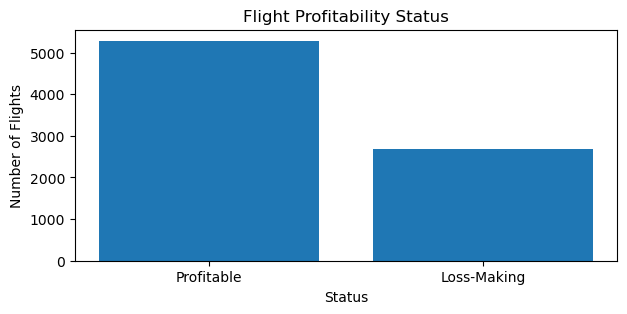

In [45]:
status_counts = df["Profitability_Status"].value_counts()

plt.figure(figsize=(7, 3))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Flight Profitability Status")
plt.xlabel("Status")
plt.ylabel("Number of Flights")

plt.show()

## 18. Route Optimization Classification

In [46]:
route_summary = (
    df.groupby("Route")
      .agg(
          Flights=("Flight_Number", "count"),
          Passengers=("Passengers", "sum"),
          Revenue=("Total_Revenue", "sum"),
          Cost=("Total_Cost", "sum"),
          Profit=("Profit", "sum"),
          Avg_Load_Factor=("Load_Factor", "mean"),
          Avg_Profit_Margin=("Profit_Margin", "mean")
      )
)

route_summary["Recommendation"] = np.select(
    [
        (route_summary["Profit"] > 0) &
        (route_summary["Avg_Load_Factor"] >= 0.75),

        (route_summary["Profit"] > 0),

        (route_summary["Profit"] <= 0)
    ],
    [
        "Expand",
        "Maintain / Improve",
        "Review / Reduce"
    ],
    default="Review"
)

route_summary.sort_values("Profit", ascending=False)

,Flights,Passengers,Revenue,Cost,Profit,Avg_Load_Factor,Avg_Profit_Margin,Recommendation
Route,,,,,,,,
DXB-FRA,325,109787,2.048922e+08,1.054007e+08,99491502.54,0.850049,46.080000,Expand
DXB-SIN,320,109749,2.039344e+08,1.129396e+08,90994879.30,0.849792,42.072750,Expand
DXB-CDG,323,110676,2.039859e+08,1.138073e+08,90178585.87,0.853367,41.265944,Expand
DXB-HKG,332,116223,2.182465e+08,1.287146e+08,89531878.76,0.851442,38.667681,Expand
DXB-JFK,328,113213,2.137032e+08,1.724657e+08,41237491.55,0.851404,15.704177,Expand
DXB-BKK,212,56490,9.495948e+07,5.439553e+07,40563948.78,0.740103,39.905236,Maintain / Improve
DXB-KUL,216,56747,9.641778e+07,5.993626e+07,36481521.99,0.727525,34.485741,Maintain / Improve
DXB-SYD,327,111906,2.053551e+08,1.742288e+08,31126294.37,0.848955,9.975076,Expand
DXB-BOM,325,93740,6.903962e+07,4.496927e+07,24070355.00,0.848457,31.157938,Expand


In [47]:
route_summary["Recommendation"].value_counts()

Recommendation
Expand                12
Maintain / Improve    10
Review / Reduce        8
Name: count, dtype: int64

## 19. Recommendation by Route

In [48]:
recommendation_summary = (
    route_summary
    .groupby("Recommendation")
    .agg(
        Routes=("Profit", "count"),
        Total_Profit=("Profit", "sum"),
        Avg_Profit_Margin=("Avg_Profit_Margin", "mean"),
        Avg_Load_Factor=("Avg_Load_Factor", "mean")
    )
    .sort_values("Total_Profit", ascending=False)
)

recommendation_summary

,Routes,Total_Profit,Avg_Profit_Margin,Avg_Load_Factor
Recommendation,,,,
Expand,12,5.048867e+08,23.018999,0.850279
Maintain / Improve,10,1.142145e+08,14.193910,0.733318
Review / Reduce,8,-4.362061e+07,-40.251874,0.763988


## 20. Top Expansion Candidates

In [49]:
route_summary[
    route_summary["Recommendation"] == "Expand"
].sort_values(
    "Profit",
    ascending=False
).head(10)

,Flights,Passengers,Revenue,Cost,Profit,Avg_Load_Factor,Avg_Profit_Margin,Recommendation
Route,,,,,,,,
DXB-FRA,325,109787,2.048922e+08,1.054007e+08,99491502.54,0.850049,46.080000,Expand
DXB-SIN,320,109749,2.039344e+08,1.129396e+08,90994879.30,0.849792,42.072750,Expand
DXB-CDG,323,110676,2.039859e+08,1.138073e+08,90178585.87,0.853367,41.265944,Expand
DXB-HKG,332,116223,2.182465e+08,1.287146e+08,89531878.76,0.851442,38.667681,Expand
DXB-JFK,328,113213,2.137032e+08,1.724657e+08,41237491.55,0.851404,15.704177,Expand
DXB-SYD,327,111906,2.053551e+08,1.742288e+08,31126294.37,0.848955,9.975076,Expand
DXB-BOM,325,93740,6.903962e+07,4.496927e+07,24070355.00,0.848457,31.157938,Expand
DXB-DEL,332,95259,6.803000e+07,4.697777e+07,21052229.00,0.852158,27.435934,Expand
DXB-IST,329,94459,6.981061e+07,5.630183e+07,13508781.50,0.849010,14.873040,Expand


## 21. Routes Requiring Review

In [50]:
route_summary[
    route_summary["Recommendation"] == "Review / Reduce"
].sort_values(
    "Profit"
).head(10)

,Flights,Passengers,Revenue,Cost,Profit,Avg_Load_Factor,Avg_Profit_Margin,Recommendation
Route,,,,,,,,
DXB-CAI,201,46011,11678327.29,1.986855e+07,-8190219.81,0.735169,-83.958159,Review / Reduce
DXB-AMM,219,50040,12448226.61,2.036120e+07,-7912976.35,0.739424,-76.294155,Review / Reduce
DXB-LAX,206,54629,87417926.51,9.532329e+07,-7905366.81,0.735038,-15.592718,Review / Reduce
DXB-LHR,344,117071,84140583.59,9.084016e+07,-6699578.75,0.850903,-13.442500,Review / Reduce
DXB-SFO,210,55545,94070676.65,1.000649e+08,-5994202.11,0.735600,-12.707810,Review / Reduce
DXB-JED,205,27608,6722705.20,1.059964e+07,-3876933.27,0.731225,-68.188488,Review / Reduce
DXB-RUH,216,29139,7278877.32,9.690177e+06,-2411299.99,0.733216,-41.197731,Review / Reduce
DXB-KWI,341,53401,15174911.77,1.580494e+07,-630031.24,0.851329,-10.633431,Review / Reduce


## 22. Final Business Summary

In [51]:
print("========== AIRLINE ROUTE PROFITABILITY SUMMARY ==========")

print("\nTotal Flights:", len(df))

print("Total Revenue:", round(df["Total_Revenue"].sum(), 2))

print("Total Cost:", round(df["Total_Cost"].sum(), 2))

print("Total Profit:", round(df["Profit"].sum(), 2))

print(
    "Overall Profit Margin:",
    round(
        (df["Profit"].sum() / df["Total_Revenue"].sum()) * 100,
        2
    ),
    "%"
)

print(
    "\nProfitable Flights:",
    (df["Profit"] > 0).sum()
)

print(
    "Loss-Making Flights:",
    (df["Profit"] < 0).sum()
)

print(
    "Break-Even Flights:",
    (df["Profit"] == 0).sum()
)

print(
    "\nMost Profitable Route:",
    route_analysis["Profit"].idxmax()
)

print(
    "Least Profitable Route:",
    route_analysis["Profit"].idxmin()
)

print(
    "\nHighest Cost Component:",
    cost_summary.idxmax()
)

========== AIRLINE ROUTE PROFITABILITY SUMMARY ==========

Total Flights: 7974
Total Revenue: 2371756240.42
Total Cost: 1796275579.39
Total Profit: 575480660.99
Overall Profit Margin: 24.26 %

Profitable Flights: 5286
Loss-Making Flights: 2688
Break-Even Flights: 0

Most Profitable Route: DXB-FRA
Least Profitable Route: DXB-CAI

Highest Cost Component: Fuel_Cost
